In [1]:
import json
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, figsize=(6, 4))
DATA_DIR = Path("../../data/raw/tcga")
PROC_DIR = Path("../../data/processed")
PROC_DIR.mkdir(exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


In [4]:
def load_star_counts(tsv_path: Path) -> pd.Series:
    """Parse a STAR counts TSV — returns unstranded gene counts."""
    df = pd.read_csv(tsv_path, sep="\t", comment="#",
                     names=["gene_id","gene_name","gene_type",
                            "unstranded","stranded_first","stranded_second"])
    df = df[~df["gene_id"].str.startswith("N_")]
    df = df.set_index("gene_id")
    df = df[~df.index.duplicated(keep="first")]   # ← fix
    return df["unstranded"]

def load_cancer_type(ct: str) -> tuple[pd.DataFrame, dict]:
    ct_dir = DATA_DIR / ct
    manifest = json.load(open(ct_dir / "manifest.json"))
    frames = {}
    for file_id, meta in manifest.items():
        file_dir = ct_dir / file_id
        tsvs = list(file_dir.glob("*.tsv"))
        if not tsvs:
            continue
        sample_id = meta["cases"][0]["submitter_id"]
        if sample_id in frames:
            continue                                # ← skip duplicate samples
        frames[sample_id] = load_star_counts(tsvs[0])
    df = pd.DataFrame(frames)
    return df, manifest

In [5]:
counts = {}
manifests = {}
for ct in ["BRCA", "LUAD", "GBM"]:
    print(f"Loading {ct}...")
    counts[ct], manifests[ct] = load_cancer_type(ct)
    print(f"  {counts[ct].shape[0]:,} genes × {counts[ct].shape[1]} samples")

Loading BRCA...
  23,366 genes × 20 samples
Loading LUAD...
  20,387 genes × 20 samples
Loading GBM...
  19,233 genes × 18 samples


In [7]:
dfs = []
for ct, df in counts.items():
    df = df.copy()
    df.columns = [f"{ct}_{c}" for c in df.columns]
    dfs.append(df)

merged = pd.concat(dfs, axis=1).fillna(0)
merged = merged.apply(pd.to_numeric, errors="coerce").fillna(0)  # ← fix
merged = merged.astype(int)

# Build obs (sample metadata)
obs_rows = []
for ct, manifest in manifests.items():
    for fid, meta in manifest.items():
        case = meta["cases"][0]
        sid  = f"{ct}_{case['submitter_id']}"
        if sid not in merged.columns:
            continue
        obs_rows.append({
            "sample_id":   sid,
            "cancer_type": ct,
            "case_id":     case["case_id"],
            "gender":      case.get("demographic", {}).get("gender", "unknown"),
            "sample_type": case["samples"][0]["sample_type"] if case.get("samples") else "unknown",
        })

obs = pd.DataFrame(obs_rows).set_index("sample_id")
obs = obs.loc[obs.index.isin(merged.columns)]
merged = merged[obs.index]

adata = ad.AnnData(X=merged.T.values,
                   obs=obs,
                   var=pd.DataFrame(index=merged.index))
adata.var_names = merged.index.tolist()
print(adata)

AnnData object with n_obs × n_vars = 60 × 33296
    obs: 'cancer_type', 'case_id', 'gender', 'sample_type'


/opt/anaconda3/envs/omicsoracle/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


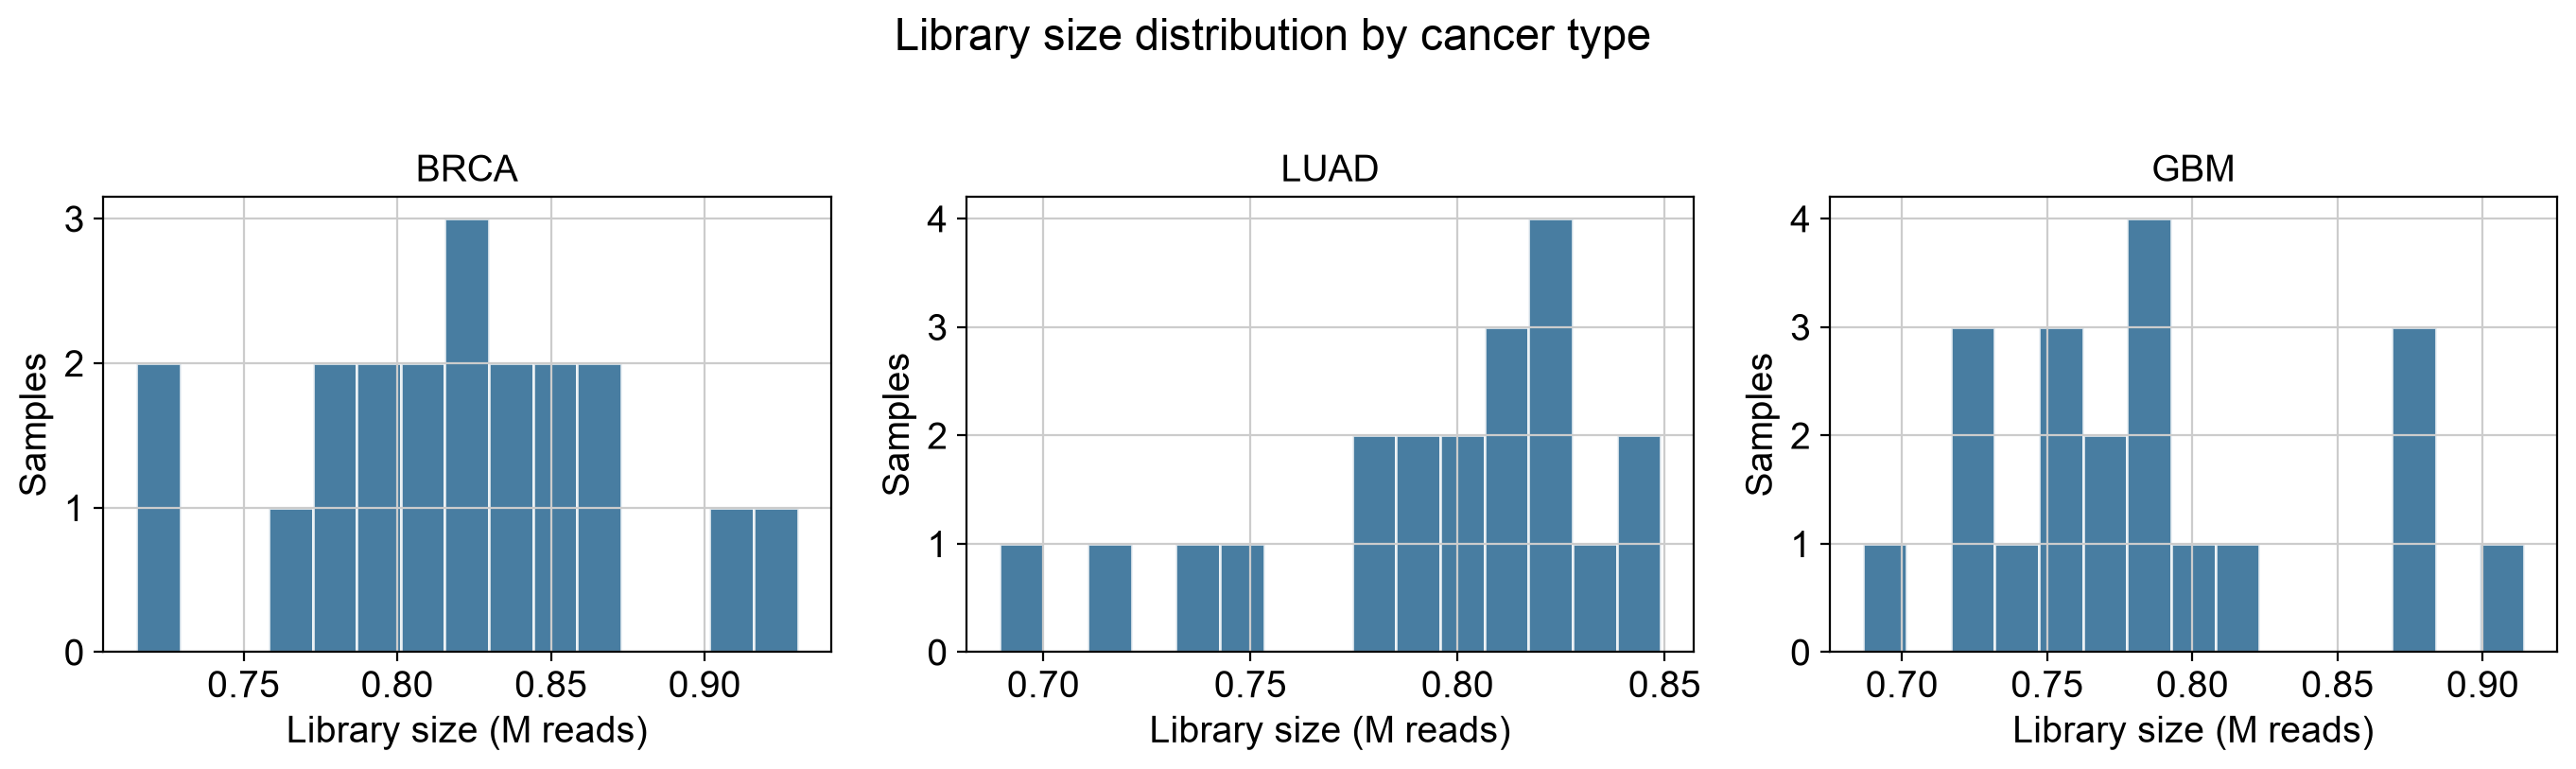

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Library size per cancer type
for ax, ct in zip(axes, ["BRCA", "LUAD", "GBM"]):
    sub = adata[adata.obs.cancer_type == ct]
    lib_sizes = sub.X.sum(axis=1)
    ax.hist(lib_sizes / 1e6, bins=15, color="#1a5c8a", alpha=0.8, edgecolor="white")
    ax.set_title(ct)
    ax.set_xlabel("Library size (M reads)")
    ax.set_ylabel("Samples")

plt.suptitle("Library size distribution by cancer type", y=1.02)
plt.tight_layout()
plt.savefig(PROC_DIR / "qc_library_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=200)
print(f"After QC: {adata.shape}")

# Save raw counts before normalization
adata.layers["counts"] = adata.X.copy()

# Normalize + log transform for EDA visualization
sc.pp.normalize_total(adata, target_sum=1e6)   # CPM
sc.pp.log1p(adata)

# PCA + UMAP
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/opt/anaconda3/envs/omicsoracle/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/omicsoracle/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


After QC: (60, 15615)


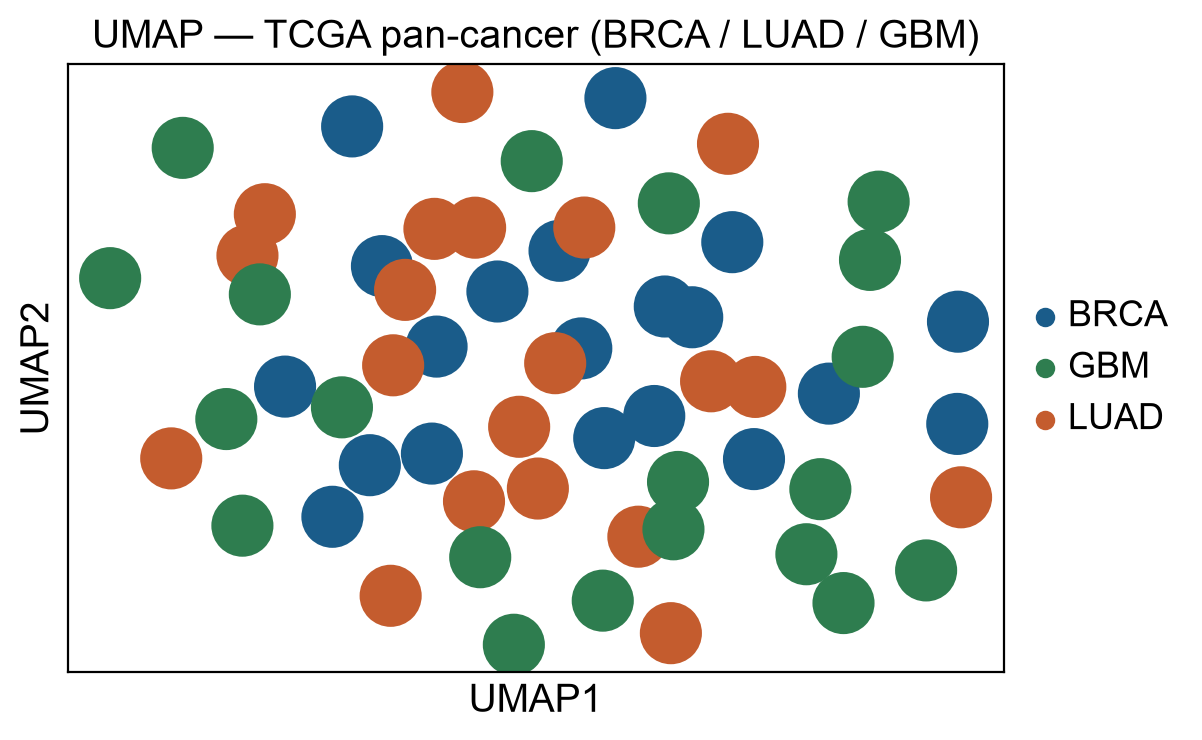

<Figure size 600x400 with 0 Axes>

In [10]:
sc.pl.umap(adata, color="cancer_type",
           palette={"BRCA": "#1a5c8a", "LUAD": "#c45c2e", "GBM": "#2e7d4f"},
           title="UMAP — TCGA pan-cancer (BRCA / LUAD / GBM)",
           save=False)
plt.savefig(PROC_DIR / "umap_cancer_type.png", dpi=150, bbox_inches="tight")

In [11]:
adata.write_h5ad(PROC_DIR / "tcga_pancancer_raw.h5ad")
print(f"Saved → {PROC_DIR / 'tcga_pancancer_raw.h5ad'}")
print(f"Shape: {adata.shape[0]} samples × {adata.shape[1]} genes")

Saved → ../../data/processed/tcga_pancancer_raw.h5ad
Shape: 60 samples × 15615 genes
